In [ ]:
# implementing simple neural network using pytorch
import torch
import torch.nn as nn

class Pinn2(nn.Module):
  def __init__(self):
    super(Pinn2,self).__init__()
    self.net=nn.Sequential(
        nn.Linear(1,64),
        nn.Tanh(),

        nn.Linear(64,1)
    )
  def forward(self,x):
    return self.net(x)
  def physics_loss(self,x):
    x.requires_grad=True
    y_pred=self(x)
    dy_dx=torch.autograd.grad(y_pred,x,grad_outputs=torch.ones_like(y_pred),create_graph=True)[0]
    dy2_dx2=torch.autograd.grad(dy_dx,x,grad_outputs=torch.ones_like(dy_dx),create_graph=True)[0]

    res=(dy2_dx2+2*dy_dx+y_pred)**2
    return torch.mean( res)


  def train_model(self,epochs,lr,x_t,x_b,y_b,x_b2,y_b2):
    optimizer=torch.optim.Adam(self.parameters(),lr)
    prv_loss=0
    loss_history=[]
    for epoch in range(epochs):
      optimizer.zero_grad()
      boundary_loss=torch.mean((self(x_b)-y_b)**2)

      boundary_loss2= torch.mean((self(x_b2)-y_b2)**2)
      Loss=(self.physics_loss(x_t)+boundary_loss+boundary_loss2)

      Loss.backward()
      optimizer.step()
      loss_history.append(Loss.item())
      curr_loss=Loss.item()
      if epoch % 200 == 0:
        if epoch>0:
          diff_loss=curr_loss-prv_loss
          print(f"Epoch {epoch:4d}: Loss {Loss.item():.6f} | differnce in loss {diff_loss:.6f}")
        else:
          print(f"Epoch {epoch:4d}: Loss {Loss.item():.6f}| no previous loss")
      prv_loss=curr_loss
    return loss_history

Epoch    0: Loss 11.711923| no previous loss
Epoch  200: Loss 3.091056 | differnce in loss -0.002032
Epoch  400: Loss 2.496086 | differnce in loss -0.003911
Epoch  600: Loss 1.656584 | differnce in loss -0.004284
Epoch  800: Loss 0.829536 | differnce in loss -0.003692
Epoch 1000: Loss 0.292299 | differnce in loss -0.001714
Epoch 1200: Loss 0.081775 | differnce in loss -0.000541
Epoch 1400: Loss 0.025938 | differnce in loss -0.000118
Epoch 1600: Loss 0.012953 | differnce in loss -0.000033
Epoch 1800: Loss 0.008796 | differnce in loss -0.000013
Epoch 2000: Loss 0.006931 | differnce in loss -0.000007
Epoch 2200: Loss 0.005697 | differnce in loss -0.000005
Epoch 2400: Loss 0.004698 | differnce in loss -0.000005
Epoch 2600: Loss 0.003853 | differnce in loss -0.000004
Epoch 2800: Loss 0.003135 | differnce in loss -0.000003
Epoch 3000: Loss 0.002520 | differnce in loss -0.000003
Epoch 3200: Loss 0.001987 | differnce in loss -0.000002
Epoch 3400: Loss 0.001521 | differnce in loss -0.000002
Epo

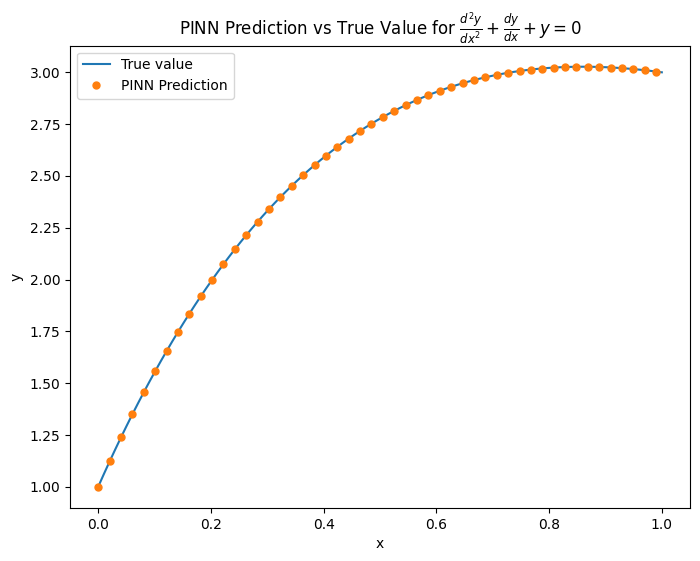

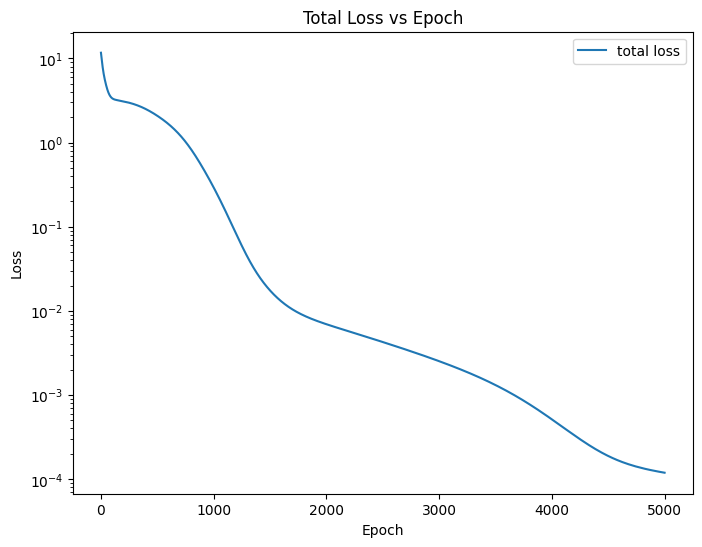

In [ ]:
#plotting
import numpy as np
import matplotlib.pyplot as plt
#  Define training points

x_tnp = np.linspace(0, 1, 100).reshape(-1, 1)
x_bnp = np.array([[0.0]])
y_bnp = np.array([[1.0]])
x_b2np=np.array([[1]])
y_b2np=np.array([[3]])
model=Pinn2()
x_t=torch.tensor(x_tnp,dtype=torch.float32)
x_b=torch.tensor(x_bnp,dtype=torch.float32)
y_b=torch.tensor(y_bnp,dtype=torch.float32)
x_b2=torch.tensor(x_b2np,dtype=torch.float32)
y_b2=torch.tensor(y_b2np,dtype=torch.float32)



loss_history=model.train_model(5000,0.001,x_t, x_b, y_b,x_b2,y_b2)
with torch.no_grad():
  y_p_t=model(x_t)
  y_pred=y_p_t.numpy()
y_true = (np.e**(-x_tnp))+(3*np.e-1)*x_tnp*(np.e**(-x_tnp))
plt.figure(figsize=(8, 6))
plt.plot(x_tnp, y_true, label="True value")
plt.plot(x_tnp, y_pred, label="PINN Prediction",marker='o',markersize=5,markevery=2,linestyle='None')
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"PINN Prediction vs True Value for $\frac{d^2y}{dx^2} +\frac{dy}{dx}+{y}= {0}$")
plt.legend()
plt.figure(figsize=(8, 6))
plt.plot(loss_history, label='total loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Total Loss vs Epoch')
plt.legend()
plt.show()
#error=np.abs(y_true-y_pred)
#print(error)

In [ ]:
# implementing simple neural network using pytorch  for second order ODE
import torch
import torch.nn as nn

class Pinn1(nn.Module):
  def __init__(self):
    super(Pinn1,self).__init__()
    self.net=nn.Sequential(
        nn.Linear(1,64),
        nn.Tanh(),
        nn.Linear(64,1)
    )
  def forward(self,x):
    return self.net(x)
  def physics_loss(self,x):
    x.requires_grad=True
    y_pred=self(x)
    dy_dx=torch.autograd.grad(y_pred,x,grad_outputs=torch.ones_like(y_pred),create_graph=True)[0]
    dy2_dx2=torch.autograd.grad(dy_dx,x,grad_outputs=torch.ones_like(dy_dx),create_graph=True)[0]
    y_t=torch.cos(x)
    res=(dy2_dx2-y_t)**2
    return torch.mean( res)


  def train_model(self,epochs,lr,x_t,x_b,y_b,x_b2,y_b2):
    optimizer=torch.optim.Adam(self.parameters(),lr)
    prv_loss=0
    loss_history=[]
    for epoch in range(epochs):
      optimizer.zero_grad()
      boundary_loss=torch.mean((self(x_b)-y_b)**2)

      boundary_loss2= torch.mean((self(x_b2)-y_b2)**2)
      Loss=(3*self.physics_loss(x_t)+boundary_loss+boundary_loss2)

      Loss.backward()
      optimizer.step()
      loss_history.append(Loss.item())
      curr_loss=Loss.item()
      if epoch % 200 == 0:
        if epoch>0:
          diff_loss=curr_loss-prv_loss
          print(f"Epoch {epoch:4d}: Loss {Loss.item():.6f} | differnce in loss {diff_loss:.6f}")
        else:
          print(f"Epoch {epoch:4d}: Loss {Loss.item():.6f}| no previous loss")
      prv_loss=curr_loss
    return loss_history

Epoch    0: Loss 4.598877| no previous loss
Epoch  200: Loss 0.932742 | differnce in loss -0.001655
Epoch  400: Loss 0.710527 | differnce in loss -0.000921
Epoch  600: Loss 0.522642 | differnce in loss -0.000937
Epoch  800: Loss 0.351705 | differnce in loss -0.000734
Epoch 1000: Loss 0.238271 | differnce in loss -0.000402
Epoch 1200: Loss 0.181097 | differnce in loss -0.000205
Epoch 1400: Loss 0.148012 | differnce in loss -0.000133
Epoch 1600: Loss 0.126635 | differnce in loss -0.000087
Epoch 1800: Loss 0.111658 | differnce in loss -0.000065
Epoch 2000: Loss 0.100132 | differnce in loss -0.000052
Epoch 2200: Loss 0.090701 | differnce in loss -0.000043
Epoch 2400: Loss 0.072614 | differnce in loss -0.000062
Epoch 2600: Loss 0.046791 | differnce in loss -0.000063
Epoch 2800: Loss 0.027084 | differnce in loss -0.000050
Epoch 3000: Loss 0.018528 | differnce in loss -0.000037
Epoch 3200: Loss 0.012249 | differnce in loss -0.000025
Epoch 3400: Loss 0.007969 | differnce in loss -0.000018
Epoc

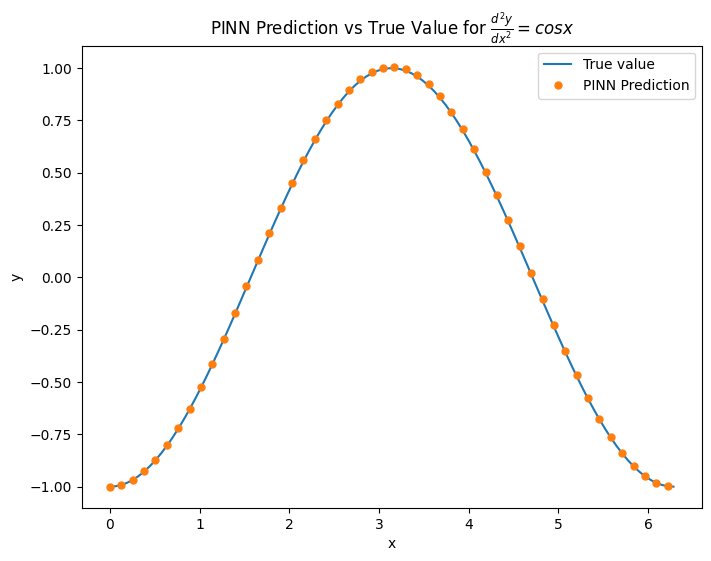

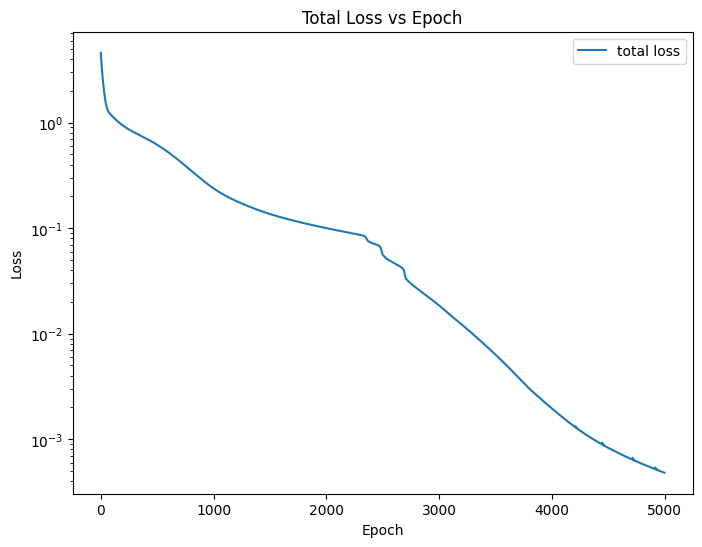

In [ ]:
#plotting
import numpy as np
import matplotlib.pyplot as plt
#  Define training points

x_tnp = np.linspace(0, 2*np.pi, 100).reshape(-1, 1)
x_bnp = np.array([[0.0]])
y_bnp = np.array([[-1.0]])
x_b2np=np.array([[2*(np.pi)]])
y_b2np=np.array([[-1.0]])
model=Pinn1()
x_t=torch.tensor(x_tnp,dtype=torch.float32)
x_b=torch.tensor(x_bnp,dtype=torch.float32)
y_b=torch.tensor(y_bnp,dtype=torch.float32)
x_b2=torch.tensor(x_b2np,dtype=torch.float32)
y_b2=torch.tensor(y_b2np,dtype=torch.float32)



loss_history=model.train_model(5000,0.001,x_t, x_b, y_b,x_b2,y_b2)
with torch.no_grad():
  y_p_t=model(x_t)
  y_pred=y_p_t.numpy()
y_true = -(np.cos(x_tnp))
plt.figure(figsize=(8, 6))
plt.plot(x_tnp, y_true, label="True value")
plt.plot(x_tnp, y_pred, label="PINN Prediction",marker='o',markersize=5,markevery=2,linestyle='None')
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"PINN Prediction vs True Value for $\frac{d^2y}{dx^2} = cos{x}$")
plt.legend()
plt.figure(figsize=(8, 6))
plt.plot(loss_history, label='total loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Total Loss vs Epoch')
plt.legend()
plt.show()

In [ ]:
# implementing simple neural network for Laplace equation in 1D
import torch
import torch.nn as nn

class Pinn3(nn.Module):
  def __init__(self):
    super(Pinn3,self).__init__()                                                                 # 2 hiddenlayers
    self.net=nn.Sequential(
        nn.Linear(1,32),
        nn.Tanh(),
        nn.Linear(32,32),
        nn.Tanh(),
        nn.Linear(32,1)
    )
  def forward(self,x):
    return self.net(x)
  def physics_loss(self,x):
    x.requires_grad=True
    y_pred=self(x)
    dy_dx=torch.autograd.grad(y_pred,x,grad_outputs=torch.ones_like(y_pred),create_graph=True)[0]
    dy2_dx2=torch.autograd.grad(dy_dx,x,grad_outputs=torch.ones_like(dy_dx),create_graph=True)[0]

    res=(dy2_dx2)**2
    return torch.mean( res)


  def train_model(self,epochs,lr,x_t,x_b,y_b,x_b2,y_b2):
    optimizer=torch.optim.Adam(self.parameters(),lr)
    prv_loss=0
    loss_history=[]
    for epoch in range(epochs):
      optimizer.zero_grad()
      boundary_loss=torch.mean((self(x_b)-y_b)**2)

      boundary_loss2= torch.mean((self(x_b2)-y_b2)**2)
      Loss=(self.physics_loss(x_t)+boundary_loss+boundary_loss2)

      Loss.backward()
      optimizer.step()
      loss_history.append(Loss.item())
      curr_loss=Loss.item()
      if epoch % 200 == 0:
        if epoch>0:
          diff_loss=curr_loss-prv_loss
          print(f"Epoch {epoch:4d}: Loss {Loss.item():.6f} | differnce in loss {diff_loss:.6f}")
        else:
          print(f"Epoch {epoch:4d}: Loss {Loss.item():.6f}| no previous loss")
      prv_loss=curr_loss
    return loss_history

Streaming output truncated to the last 5000 lines.
Epoch 1000000: Loss 0.000012 | differnce in loss 0.000009
Epoch 1000200: Loss 0.000007 | differnce in loss 0.000001
Epoch 1000400: Loss 0.000000 | differnce in loss 0.000000
Epoch 1000600: Loss 0.000000 | differnce in loss -0.000000
Epoch 1000800: Loss 0.000000 | differnce in loss 0.000000
Epoch 1001000: Loss 0.000011 | differnce in loss -0.000002
Epoch 1001200: Loss 0.000000 | differnce in loss -0.000000
Epoch 1001400: Loss 0.000000 | differnce in loss -0.000000
Epoch 1001600: Loss 0.000000 | differnce in loss -0.000000
Epoch 1001800: Loss 0.000000 | differnce in loss 0.000000
Epoch 1002000: Loss 0.000001 | differnce in loss 0.000000
Epoch 1002200: Loss 0.000000 | differnce in loss -0.000000
Epoch 1002400: Loss 0.000027 | differnce in loss 0.000007
Epoch 1002600: Loss 0.000000 | differnce in loss 0.000000
Epoch 1002800: Loss 0.000000 | differnce in loss -0.000000
Epoch 1003000: Loss 0.000000 | differnce in loss 0.000000
Epoch 1003200:

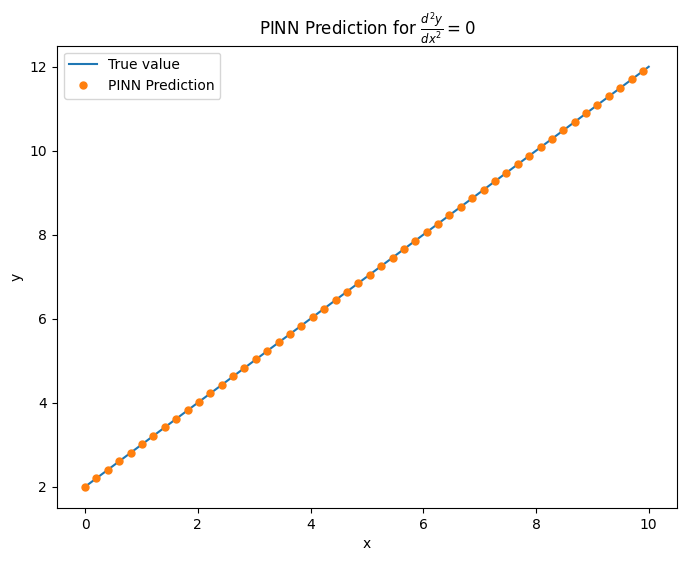

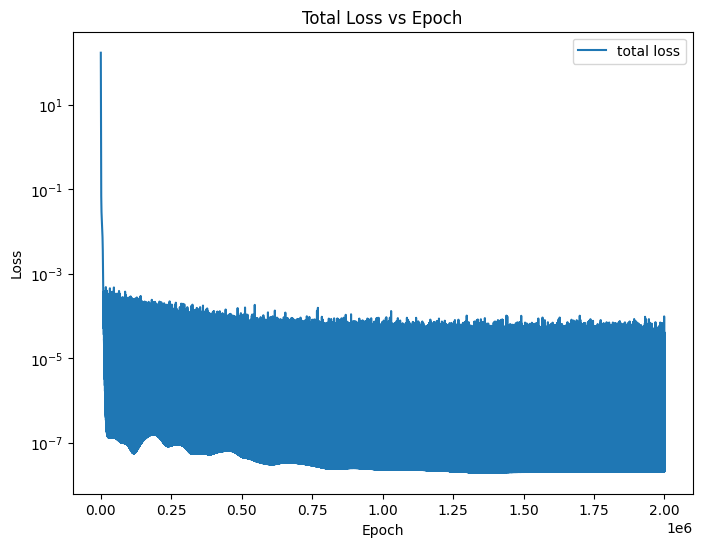

In [ ]:
#plotting
import numpy as np
import matplotlib.pyplot as plt
#  Define training points

x_tnp = np.linspace(0, 10, 100).reshape(-1, 1)
x_bnp = np.array([[0.0]])
y_bnp = np.array([[2.0]])
x_b2np=np.array([[10]])
y_b2np=np.array([[12.0]])
model=Pinn3()
x_t=torch.tensor(x_tnp,dtype=torch.float32)
x_b=torch.tensor(x_bnp,dtype=torch.float32)
y_b=torch.tensor(y_bnp,dtype=torch.float32)
x_b2=torch.tensor(x_b2np,dtype=torch.float32)
y_b2=torch.tensor(y_b2np,dtype=torch.float32)



loss_history=model.train_model(2*10**6,0.0005,x_t, x_b, y_b,x_b2,y_b2)
with torch.no_grad():
  y_p_t=model(x_t)
  y_pred=y_p_t.numpy()
y_true = x_tnp+2
plt.figure(figsize=(8, 6))
plt.plot(x_tnp, y_true, label="True value")
plt.plot(x_tnp, y_pred, label="PINN Prediction",marker='o',markersize=5,markevery=2,linestyle='None')
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"PINN Prediction for $\frac{d^2y}{dx^2} = {0}$")
plt.legend()
plt.figure(figsize=(8, 6))
plt.plot(loss_history, label='total loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Total Loss vs Epoch')
plt.legend()
plt.show()